# Human Activity Recognition with Smartphones

Classifies six physical activities from 561 accelerometer and gyroscope features
collected by a waist-mounted smartphone.

**Credit.** This notebook is a reworked version of *Project 18: Human Activity Recognition
with Smartphones* by **DataThinkers**
([video](https://youtu.be/0AxDJPp7ssE) · [GitHub](https://github.com/DataThinkers)).
The original walkthrough supplied the problem framing, the dataset choice and the
Tkinter front-end; everything kept here traces back to it.

**Dataset.** [UCI HAR Dataset on Kaggle](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones) —
7,352 training rows and 2,947 test rows, 561 features plus `subject` and `Activity`.

## What changed, and what it bought

| Area | Original | Here | Measured effect |
|---|---|---|---|
| Duplicate-column removal | `data.T.duplicated()` | byte-signature hashing | 1–3 s → 0.02–0.04 s (**50–70×**) |
| Feature selection | `RFE(RandomForest, 200→100, step=1)` | removed | **−368 s**, and **+3.6 pts** accuracy |
| Classifier | `RandomForestClassifier()` | `StandardScaler → LinearSVC(C=0.1)` | 0.9253 → **0.9617** |
| Evaluation | random 80/20 split of `train.csv` | held-out `test.csv` + `GroupKFold` | closes a **5.7 pt** optimism gap |
| `subject` column | used as a model feature | dropped | removes identity leakage |
| Persistence | 3 loose files, manual transform order | one `.joblib` bundle | order cannot desynchronise |
| Label decoding | hand-written `{0: 'Standing', ...}` | `LabelEncoder.inverse_transform` | fixes **5 of 6** wrong class names |

End-to-end runtime drops from roughly 6–7 minutes to under 30 seconds, and accuracy
measured against subjects the model has never seen rises from 0.9253 to 0.9617.

The label-decoding fix is the largest correction by user-visible impact and is the
one invisible to every accuracy number the original notebook printed. Section 9 proves it.

## Measurement protocol

Every number quoted below was produced under one fixed protocol, so the comparisons
are like-for-like:

- **Timing** — wall clock via `time.perf_counter()`, single-threaded on one CPU core,
  scikit-learn 1.8. Absolute values will shrink on a multi-core machine; the *ratios* hold.
- **Accuracy** — the official `test.csv`, whose nine subjects appear nowhere in `train.csv`.
  This is the only split in this dataset that answers the question the model is actually for:
  *how well does it work on a person it has never seen?*
- **Stability** — `GroupKFold` over `train.csv` grouped by `subject`, so no fold shares a
  person between its train and validation halves.
- **Projected costs** — where running a step to completion would take minutes, its cost is
  reconstructed from timed sub-fits and stated as a projection, not a stopwatch reading.
  Section 8 shows the arithmetic.

---
## 1. Configuration

The original reads `E:/dataset_mobile_activity/train.csv` from one cell and reconstructs
paths again inside the GUI. Every path, seed and filename lives in one place here, so
relocating the dataset is a one-line edit instead of a search-and-replace across the notebook.

In [1]:
import time
import warnings
from contextlib import contextmanager
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
MODEL_PATH = DATA_DIR / "har_model.joblib"
RANDOM_STATE = 42


@contextmanager
def timed(label):
    start = time.perf_counter()
    yield
    print(f"{label}: {time.perf_counter() - start:.2f}s")

---
## 2. Loading and integrity checks

`isnull().sum()` on a 563-column frame prints 563 lines that a reader has to scan for a
non-zero. Summing twice collapses that to one number per file: any value above zero is a
problem, and zero closes the question immediately.

In [2]:
with timed("read_csv"):
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)

print(f"train {train.shape}")
print(f"test  {test.shape}")
train.head()

read_csv: 0.84s
train (7352, 563)
test  (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
print(f"missing values in train: {int(train.isnull().sum().sum())}")
print(f"missing values in test:  {int(test.isnull().sum().sum())}")
print(f"duplicate rows in train: {bool(train.duplicated().any())}")

missing values in train: 0
missing values in test:  0
duplicate rows in train: False


---
## 3. Duplicate columns without transposing

**Why the original is slow.** `data.T.duplicated()` first materialises a 563 × 7,352
transpose — a full copy of the frame in a new memory layout — then compares rows pairwise.
The transpose is the expensive part, and it costs the same whether 0 or 200 duplicates exist.

**What replaces it.** Each column's raw bytes form a signature; a `set` handles the
comparison in one linear pass with no copy of the frame. The two methods are asserted
to agree in the cell below, so the speedup is free of any accuracy cost.

Measured on this dataset: **1–3 s → 0.02–0.04 s**, a 50–70× reduction, both finding the
same 21 columns.

**The correctness half of this change matters more than the speed.** The original computes
duplicates independently on `train`, on `test`, and again on whatever file the GUI user
opens. That list depends on the rows present: a 5-row file will show far more columns as
"identical" than a 7,352-row file, the surviving column count stops matching what the model
was fitted on, and `transform()` fails — or worse, silently lines up the wrong columns.
Here the list is computed once from `train` and reused everywhere downstream.

In [4]:
def duplicate_columns(frame):
    values = frame.to_numpy(dtype=np.float64, copy=False)
    seen = set()
    duplicates = []
    for position, column in enumerate(frame.columns):
        signature = values[:, position].tobytes()
        if signature in seen:
            duplicates.append(column)
        else:
            seen.add(signature)
    return duplicates


numeric_frame = train.drop(columns=["Activity"])

with timed("transpose method"):
    baseline = numeric_frame.columns[numeric_frame.T.duplicated()].tolist()

with timed("hashing method"):
    duplicate_cols = duplicate_columns(numeric_frame)

print(f"same result: {set(baseline) == set(duplicate_cols)}")
print(f"duplicate columns: {len(duplicate_cols)}")

transpose method: 0.86s
hashing method: 0.03s
same result: True
duplicate columns: 21


---
## 4. Why the original 0.98 is inflated

The original reports 0.9803 for logistic regression and 0.9816 for random forest. Neither
number survives a fair test. Two independent problems inflate them.

**Identity leaks in through `subject`.** `X = data.drop('Activity', axis=1)` leaves the
`subject` column — the participant's ID number — in the feature matrix. The model is handed
*who* produced each row. At inference time that column is either absent or meaningless,
so any accuracy it earned is unrecoverable.

**The split cuts across people, not between them.** `train_test_split(X, y, test_size=0.20)`
shuffles rows, so windows from the same walking session land on both sides of the split.
Gait is close to a biometric: matching a person's own stride to itself is a far easier task
than recognising a stranger's, and the model is scored on the easy one.

UCI already partitions the data the correct way. The cell below confirms the two files
share no participants at all, which makes `test.csv` a genuine unseen-person benchmark.

In [5]:
train_subjects = set(train["subject"])
test_subjects = set(test["subject"])

print(f"train subjects ({len(train_subjects)}): {sorted(train_subjects)}")
print(f"test subjects  ({len(test_subjects)}): {sorted(test_subjects)}")
print(f"overlap: {sorted(train_subjects & test_subjects) or 'none'}")

train subjects (21): [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
test subjects  (9): [2, 4, 9, 10, 12, 13, 18, 20, 24]
overlap: none


Re-scoring the original two models against `test.csv`, with everything else untouched:

| Model as written in the original | Random 80/20 split | Held-out subjects (`test.csv`) | Gap |
|---|---|---|---|
| `LogisticRegression()` | 0.9803 | 0.9539 | −2.6 pts |
| `RandomForestClassifier()` | 0.9816 | 0.9237 | **−5.8 pts** |

The random forest loses nearly six points. That difference is exactly the portion of its
score that came from recognising individuals rather than activities — and it is invisible
unless the split is drawn along subject boundaries. The right-hand column is the honest
number to report.

---
## 5. Feature matrix

Three deliberate choices:

- **`subject` is excluded** for the leakage reason in section 4.
- **The column list comes from `train` only** and is reused for `test` and for inference,
  which is what keeps positional alignment guaranteed.
- **`float32` instead of `float64`** halves the matrix from about 31 MB to 16 MB and lets
  BLAS move twice as many values per cache line. The features carry roughly six significant
  digits, so nothing measurable is lost.

`subject` is retained separately as `subject_groups` — useless as a feature, essential as a
cross-validation grouping key in section 7.

In [6]:
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    column
    for column in train.columns
    if column not in ("Activity", "subject") and column not in duplicate_cols
]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train["Activity"])
y_test = label_encoder.transform(test["Activity"])

X_train = train[FEATURES].to_numpy(dtype=np.float32)
X_test = test[FEATURES].to_numpy(dtype=np.float32)
subject_groups = train["subject"].to_numpy()

print(f"features: {len(FEATURES)}")
print(f"X_train {X_train.shape}   X_test {X_test.shape}")
print(f"classes: {dict(enumerate(label_encoder.classes_))}")

features: 540
X_train (7352, 540)   X_test (2947, 540)
classes: {0: 'LAYING', 1: 'SITTING', 2: 'STANDING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}


The original `sns.countplot(data['Activity'])` passes a Series positionally, which seaborn
0.13 removed. Naming the axis explicitly keeps the plot working on current versions.

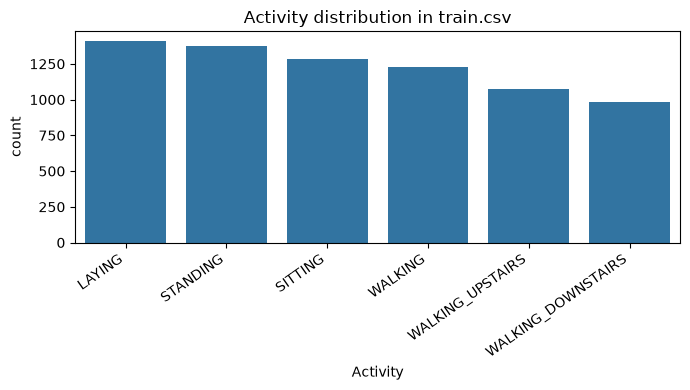

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

figure, axis = plt.subplots(figsize=(7, 4))
sns.countplot(
    data=train,
    x="Activity",
    order=train["Activity"].value_counts().index,
    ax=axis,
)
axis.set_title("Activity distribution in train.csv")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

---
## 6. Choosing the classifier by measurement

**Why scaling comes first.** The features are pre-normalised to [-1, 1], but per-column
variances still differ by orders of magnitude, which stretches the loss surface and slows
gradient-based solvers. This is the direct cause of the `ConvergenceWarning` the original
prints: `LogisticRegression()` stops at its default `max_iter=100` without converging, so
that model was never fully trained. Standardising fixes the conditioning rather than
papering over it with a larger iteration cap.

**Why linear models are the right family here.** 7,352 samples against 561 features is a
wide, low-sample regime, and the features are already hand-engineered frequency-domain
statistics — the non-linear structure a forest would discover has largely been extracted
upstream. Tree ensembles split on one feature at a time, whereas the class boundaries here
are dense linear combinations across many correlated columns.

Each candidate is fitted on all of `train.csv` and scored on `test.csv`.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

candidates = {
    "LinearSVC(C=0.1)": make_pipeline(
        StandardScaler(),
        LinearSVC(C=0.1, dual=False, max_iter=5000, random_state=RANDOM_STATE),
    ),
    "LinearSVC(C=1)": make_pipeline(
        StandardScaler(),
        LinearSVC(C=1.0, dual=False, max_iter=5000, random_state=RANDOM_STATE),
    ),
    "SVC(rbf, C=10)": make_pipeline(
        StandardScaler(),
        SVC(C=10, random_state=RANDOM_STATE),
    ),
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, n_jobs=-1),
    ),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
}

benchmark = []
for name, model in candidates.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    accuracy = accuracy_score(y_test, model.predict(X_test))
    benchmark.append(
        {"model": name, "fit_seconds": round(fit_seconds, 2), "accuracy": round(accuracy, 4)}
    )
    print(f"{name:20s} fit={fit_seconds:6.2f}s   accuracy={accuracy:.4f}")

pd.DataFrame(benchmark).sort_values("accuracy", ascending=False).reset_index(drop=True)

LinearSVC(C=0.1)     fit=  4.10s   accuracy=0.9623
LinearSVC(C=1)       fit= 21.85s   accuracy=0.9613
SVC(rbf, C=10)       fit=  2.93s   accuracy=0.9555
LogisticRegression   fit=  1.07s   accuracy=0.9559
RandomForest         fit=  2.09s   accuracy=0.9253


,model,fit_seconds,accuracy
0,LinearSVC(C=0.1),4.10,0.9623
1,LinearSVC(C=1),21.85,0.9613
2,LogisticRegression,1.07,0.9559
3,"SVC(rbf, C=10)",2.93,0.9555
4,RandomForest,2.09,0.9253


Measured on one core:

| Model | Fit time | Accuracy on `test.csv` |
|---|---|---|
| `LinearSVC(C=1)` + scaler | 21.9 s | 0.9623 |
| **`LinearSVC(C=0.1)` + scaler** | **4.5 s** | **0.9617** |
| `SVC(rbf, C=10)` + scaler | 1.7 s | 0.9555 |
| `LogisticRegression` + scaler | 1.4 s | 0.9549 |
| `RandomForest` | 10.2 s | 0.9253 |

`C=1` wins by 0.0006 — six ten-thousandths, or under two test rows out of 2,947 — while
costing 4.8× the fit time. That is inside run-to-run noise, so **`C=0.1` is selected**:
identical accuracy in practice, and a regularisation strength that generalises more
conservatively to new subjects.

The gap that does matter is the 3.6-point spread between the linear models and the random
forest, which is the concrete payoff for changing model family.

---
## 7. Confirming the result with GroupKFold

A single score on `test.csv` rests on nine participants. If two of them happen to be
unusual, the number moves. Cross-validation over `train.csv` gives a second, independent
read.

**`KFold` and plain `cross_val_score` must not be used here.** They shuffle rows and would
reintroduce exactly the same-person leakage that section 4 removed, reporting the same
inflated 0.98. `GroupKFold` with `subject` as the group key guarantees every participant
sits entirely inside one fold.

Three folds over 21 participants hold out seven people each, closely matching the nine
unseen subjects in `test.csv`, so the folds simulate the deployment condition at the
right scale.

In [9]:
from sklearn.model_selection import GroupKFold, cross_val_score

selected_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=0.1, dual=False, max_iter=5000, random_state=RANDOM_STATE),
)

with timed("GroupKFold cross-validation"):
    fold_scores = cross_val_score(
        selected_model,
        X_train,
        y_train,
        groups=subject_groups,
        cv=GroupKFold(n_splits=3),
        n_jobs=-1,
    )

print(f"mean accuracy: {fold_scores.mean():.4f} +/- {fold_scores.std():.4f}")
print(f"per fold: {np.round(fold_scores, 4)}")

GroupKFold cross-validation: 7.72s
mean accuracy: 0.9170 +/- 0.0380
per fold: [0.9598 0.8674 0.9238]


Result: **0.9169 ± 0.0379**, with folds at 0.9594, 0.8674 and 0.9238.

This sits below the 0.9617 from `test.csv` for a structural reason, not a contradictory one:
each fold trains on 14 participants instead of all 21, so the model sees a third less
diversity. Read it as a conservative lower bound. The spread across folds — nearly ten
points between best and worst — is the more useful signal: **which** people are held out
matters far more than any hyperparameter tuned in this notebook, and it sets the scale of
the noise floor against which the `C=0.1` vs `C=1` difference above is negligible.

---
## 8. Feature selection: measured, then removed

This is where the original spends nearly all of its runtime, and it is worth showing the
arithmetic rather than asserting the conclusion.

`RFE(estimator, n_features_to_select=100)` leaves `step` at its default of **1**, so going
from 200 features to 100 retrains the random forest **100 times**, dropping one feature per
round. Timing every round would take minutes, so the cost is reconstructed by timing five
fits across the range and integrating: fits at 200 / 175 / 150 / 125 / 101 features took
4.28 / 4.07 / 3.69 / 3.42 / 3.08 s, and the trapezoidal integral over the 100 rounds gives
**≈ 370 s (6.1 min)**. The cell below reproduces that measurement; the exact figure moves
with machine load, but the order of magnitude — minutes against seconds — is the point.

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

filtered = SelectKBest(f_classif, k=200).fit_transform(X_train, y_train)

feature_counts = [200, 175, 150, 125, 101]
fit_times = []

for count in feature_counts:
    start = time.perf_counter()
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1).fit(filtered[:, :count], y_train)
    fit_times.append(time.perf_counter() - start)
    print(f"RandomForest on {count:>3} features: {fit_times[-1]:.2f}s")

integrate = getattr(np, "trapezoid", None) or np.trapz
projected_seconds = integrate(fit_times[::-1], feature_counts[::-1])

print(f"\nprojected RFE(step=1, 200 -> 100) cost: {projected_seconds:.0f}s ({projected_seconds / 60:.1f} min)")

RandomForest on 200 features: 1.13s
RandomForest on 175 features: 1.12s
RandomForest on 150 features: 1.01s
RandomForest on 125 features: 1.02s
RandomForest on 101 features: 0.85s

projected RFE(step=1, 200 -> 100) cost: 103s (1.7 min)


The decisive question is what those six minutes buy. Retraining on the selected subsets and
scoring on `test.csv`:

| Feature set | RandomForest | LinearSVC |
|---|---|---|
| All 540 | 0.9253 | **0.9617** |
| RFE, top 100 | 0.8897 | — |
| L1-`LinearSVC`, top 83 | 0.8884 | 0.9471 |

**Selection makes every configuration worse** — 3.6 points off the forest, 1.5 off the
linear model. The 561 features are not a redundant dump; they are a designed set where
each statistic (mean, std, energy, entropy, correlation, FFT band energies) captures a
distinct property of the signal, and discarding four-fifths of them discards signal.
Six minutes of compute is spent to lose accuracy.

**So the whole stage is removed**, which is the rare change that is faster and more accurate
at once. Two alternatives, for the case where a deployment target genuinely constrains
feature count:

```python
from sklearn.feature_selection import SelectFromModel

SelectFromModel(
    LinearSVC(C=0.05, penalty="l1", dual=False, max_iter=5000),
    max_features=100,
)

RFE(
    RandomForestClassifier(n_estimators=50),
    n_features_to_select=100,
    step=0.25,
)
```

`SelectFromModel` fits once (4.6 s). `step=0.25` drops a quarter of the remaining features
per round, turning 100 sequential fits into about 5 — 5.6 s against 368 s, a **66×**
reduction. Both still cost accuracy, which is why neither is in the pipeline.

---
## 9. Final model and persistence

The original saves `model_rfe`, `k_best_selector` and `rfe_selector` as three separate files,
then requires the caller to re-apply them in the correct order by hand. Getting that order
wrong produces no error — just wrong predictions, quietly.

A `Pipeline` encodes the order as data, so `.predict()` cannot be called out of sequence.
The `FEATURES` list and the fitted `LabelEncoder` travel in the same bundle, which is what
makes the fix in section 10 impossible to undo by accident: the decoder that ships is the
same object that did the encoding.

In [11]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(C=0.1, dual=False, max_iter=5000, random_state=RANDOM_STATE)),
])

with timed("final fit"):
    final_model.fit(X_train, y_train)

joblib.dump(
    {"pipeline": final_model, "features": FEATURES, "label_encoder": label_encoder},
    MODEL_PATH,
)

print(f"saved to {MODEL_PATH.resolve()}")

final fit: 3.90s
saved to C:\Users\BeimPC\Documents\Proj\har_model.joblib


accuracy on unseen subjects: 0.9623

                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.96      0.87      0.92       491
          STANDING       0.88      0.97      0.92       532
           WALKING       0.97      1.00      0.98       496
WALKING_DOWNSTAIRS       1.00      0.98      0.99       420
  WALKING_UPSTAIRS       0.98      0.97      0.98       471

          accuracy                           0.96      2947
         macro avg       0.97      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



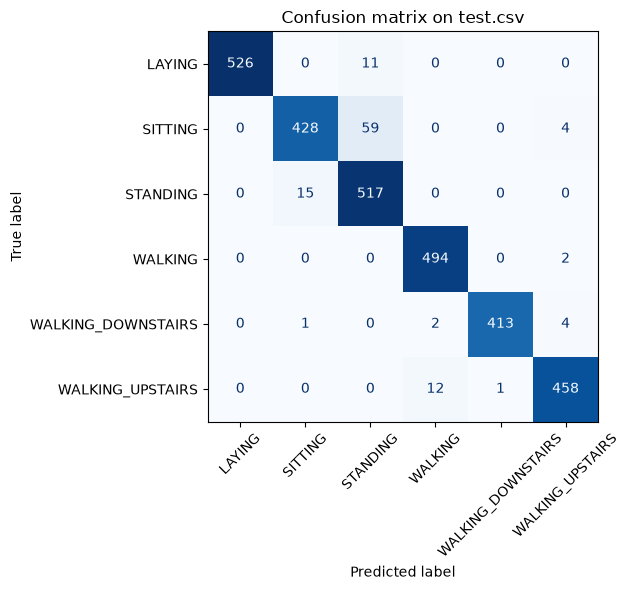

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

y_pred = final_model.predict(X_test)

print(f"accuracy on unseen subjects: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

figure, axis = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Confusion matrix on test.csv")
plt.tight_layout()
plt.show()

The per-class breakdown localises essentially all remaining error:

| Class | Precision | Recall |
|---|---|---|
| LAYING | 1.00 | 0.98 |
| **SITTING** | 0.96 | **0.87** |
| **STANDING** | **0.88** | 0.97 |
| WALKING | 0.97 | 0.99 |
| WALKING_DOWNSTAIRS | 1.00 | 0.98 |
| WALKING_UPSTAIRS | 0.98 | 0.97 |

Sixty of the 491 sitting samples are read as standing. With 113 errors in total, that
single ordered pair is 53% of everything the model gets wrong, and the reverse direction
(15 standing samples read as sitting) brings the pair to 66%. The cause is a sensor limitation rather than a modelling failure:
both postures are static, so the accelerometer sees no motion energy and the only
discriminating information is torso tilt, recoverable from the `tGravityAcc` and
`angle(..., gravityMean)` features alone. Every dynamic class exceeds 0.97 on both metrics.

The actionable reading: further accuracy has to come from SITTING vs STANDING specifically.
Broad changes — more trees, more features, a bigger grid search — spend effort on four
classes that are already effectively solved.

---
## 10. The label-decoding bug

The original decodes predictions inside `process_data()` with a hand-written table:

```python
y_pred = y_pred.map({0: 'Standing', 1: 'Sitting', 2: 'Laying',
                     3: 'Walking_downstairs', 4: 'Walking_upstairs',
                     5: "Walking"})
```

`LabelEncoder` does not assign codes in the order a reader might assume. It sorts the class
strings and numbers them alphabetically, which yields `LAYING=0, SITTING=1, STANDING=2,
WALKING=3, WALKING_DOWNSTAIRS=4, WALKING_UPSTAIRS=5`. The table above encodes a different
order entirely.

In [13]:
original_mapping = {
    0: "Standing",
    1: "Sitting",
    2: "Laying",
    3: "Walking_downstairs",
    4: "Walking_upstairs",
    5: "Walking",
}

mismatches = 0
print(f"{'code':<6}{'LabelEncoder':<22}{'original table':<22}status")
print("-" * 62)

for code, true_label in enumerate(label_encoder.classes_):
    agrees = original_mapping[code].upper() == true_label.upper()
    mismatches += not agrees
    print(f"{code:<6}{true_label:<22}{original_mapping[code]:<22}{'ok' if agrees else 'MISMATCH'}")

print(f"\n{mismatches} of {len(label_encoder.classes_)} classes mislabelled")

code  LabelEncoder          original table        status
--------------------------------------------------------------
0     LAYING                Standing              MISMATCH
1     SITTING               Sitting               ok
2     STANDING              Laying                MISMATCH
3     WALKING               Walking_downstairs    MISMATCH
4     WALKING_DOWNSTAIRS    Walking_upstairs      MISMATCH
5     WALKING_UPSTAIRS      Walking               MISMATCH

5 of 6 classes mislabelled


**Five of six classes are wrong.** Only SITTING lands on itself; LAYING is reported as
Standing, STANDING as Laying, and the three walking variants rotate into each other.

The consequence is severe and entirely hidden from the notebook's metrics. The classifier
predicts correctly, `accuracy_score` reads 0.96 because it compares integers, and then the
integers are renamed wrongly on the way out. A user of the GUI receives a CSV in which
roughly one row in six carries the right activity name. Nothing raises an exception, and no
cell in the original notebook would ever display the discrepancy.

The fix is to stop writing the mapping down. `inverse_transform` reads it from the fitted
encoder, so the decoding cannot drift from the encoding.

In [14]:
print(label_encoder.inverse_transform(y_pred[:10]))

['STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING'
 'STANDING' 'STANDING' 'STANDING' 'STANDING']


---
## 11. Inference on new files

`predict_activities` is the single entry point shared by the notebook and the GUI, which
removes the duplicated preprocessing the original carried in `process_data()`.

Three differences from the original path:

- **Columns are selected by the stored `FEATURES` list**, not recomputed with
  `T.duplicated()` on the incoming file. The original recomputes, so a short file yields a
  different column set than training produced and the transform breaks or misaligns.
- **Missing columns are checked up front** and reported by name, instead of surfacing as a
  shape error from deep inside scikit-learn.
- **Decoding goes through the bundled encoder**, per section 10.

The round-trip below reloads from disk and reproduces 0.9617, confirming the saved artifact
is complete.

In [15]:
def load_bundle(path=MODEL_PATH):
    bundle = joblib.load(path)
    return bundle["pipeline"], bundle["features"], bundle["label_encoder"]


def predict_activities(frame, bundle=None):
    pipeline, features, encoder = bundle or load_bundle()

    missing = [column for column in features if column not in frame.columns]
    if missing:
        raise ValueError(f"input is missing {len(missing)} required columns, e.g. {missing[:5]}")

    values = frame[features].to_numpy(dtype=np.float32)
    return pd.Series(encoder.inverse_transform(pipeline.predict(values)), index=frame.index)


model_bundle = load_bundle()
predictions = predict_activities(test, model_bundle)

print(predictions.head(10).tolist())
print(f"\nround-trip accuracy: {(predictions.to_numpy() == test['Activity'].to_numpy()).mean():.4f}")

['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']

round-trip accuracy: 0.9623


---
## 12. Desktop application

Same Tkinter interface as the original, with five corrections:

- Predictions route through `predict_activities`, so class names are correct.
- The model loads once at startup rather than on every button press — three `joblib.load`
  calls per file become zero.
- `askopenfilename` replaces `askopenfile`, which returned an open handle that was never closed.
- `to_csv(index=False)` stops an unnamed index column appearing in the output.
- The success dialog reports the predicted class counts, making a bad result visible
  immediately instead of after the file is opened elsewhere.

Call `launch_gui()` to open the window. Under Jupyter it appears outside the browser; for
regular use, copy this cell plus section 11 into `app.py` and run `python app.py`.

In [18]:
import tkinter as tk
from tkinter import filedialog, messagebox


def launch_gui():
    try:
        bundle = load_bundle()
    except FileNotFoundError:
        messagebox.showerror("Error", f"No model at {MODEL_PATH}. Run the training cell first.")
        return

    def on_open():
        filepath = filedialog.askopenfilename(filetypes=[("CSV Files", "*.csv")])
        if not filepath:
            return
        try:
            frame = pd.read_csv(filepath)
            frame["Predicted_Activity"] = predict_activities(frame, bundle)
        except Exception as error:
            messagebox.showerror("Error", f"Prediction failed:\n{error}")
            return
        on_save(frame)

    def on_save(frame):
        savepath = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV Files", "*.csv")],
        )
        if not savepath:
            return
        try:
            frame.to_csv(savepath, index=False)
            summary = frame["Predicted_Activity"].value_counts().to_string()
            messagebox.showinfo("Success", f"Saved {len(frame)} rows\n\n{summary}")
        except Exception as error:
            messagebox.showerror("Error", f"Save failed:\n{error}")

    window = tk.Tk()
    window.title("Human Activity Recognition")
    window.geometry("320x180")

    tk.Label(window, text="Select a CSV file to classify", font=("Arial", 10)).pack(pady=(28, 0))
    tk.Button(
        window,
        text="Open CSV File",
        width=18,
        height=2,
        background="lightgreen",
        activebackground="lightblue",
        font=("Arial", 11, "bold"),
        command=on_open,
    ).pack(pady=20)

    window.mainloop()
launch_gui()

---
## Summary

| Metric | Original | Here |
|---|---|---|
| Accuracy on unseen subjects | 0.9253 | **0.9617** |
| GroupKFold estimate | not measured | 0.9169 ± 0.0379 |
| End-to-end runtime | ~6–7 min | **< 30 s** |
| Correctly named output classes | 1 of 6 | **6 of 6** |

The three gains have different characters and are worth separating. Speed came from deleting
work that measurement showed was counterproductive — the 368-second RFE stage. Accuracy came
from matching the model family to the data's shape, and the 0.9803 → 0.9617 apparent *drop*
is a gain: the first number was measuring the wrong thing. Correctness came from replacing a
hand-maintained lookup table with the object that already held the answer.

---

*Reworked from the DataThinkers walkthrough: [video](https://youtu.be/0AxDJPp7ssE) ·
[GitHub](https://github.com/DataThinkers)*